# Import important libraries and read data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

In [2]:
data = pd.read_csv('/content/healthcare-dataset-stroke-data.csv')

# Data Pre-Processing

In [3]:
data.head(8)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1


In [4]:
data.shape

(5110, 12)

In [5]:
# Drop the unnecessary columns
data.drop(['id'], axis=1, inplace=True)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


**bmi contains 201 null value**

In [7]:
data.dropna(inplace= True)

**Encoding the categorical data**

**gender column**

In [8]:
data['gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [9]:
data['gender'].value_counts()

,count
gender,
Female,2897
Male,2011
Other,1


In [10]:
#drop the other gender type
data = data[data['gender'] != 'Other']

In [11]:
data['gender'].value_counts()

,count
gender,
Female,2897
Male,2011


In [12]:
# encode male with 1 and female to 0
data['gender'] = [1 if value == 'Male' else 0 for value in data['gender']]

In [13]:
data['gender'].unique()

array([1, 0])

**ever_married column**

In [14]:
data['ever_married'].unique()

array(['Yes', 'No'], dtype=object)

In [15]:
# encode the boolean values
data['ever_married'] = [1 if value == 'Yes' else 0 for value in data['ever_married']]

In [16]:
data['ever_married'].unique()

array([1, 0])

**work_type column**

In [17]:
data['work_type'].unique()

array(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'],
      dtype=object)

In [18]:
data['work_type'].value_counts()

,count
work_type,
Private,2810
Self-employed,775
children,671
Govt_job,630
Never_worked,22


In [19]:
# Create the encoder using sklearn
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = encoder.fit_transform(data[['work_type']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['work_type']))

#Encode the values
data = pd.concat([data.drop('work_type', axis=1), encoded_df], axis=1)

In [20]:
data.shape

(5101, 14)

**Residence_type columns**

In [21]:
data['Residence_type'].unique()

array(['Urban', 'Rural', nan], dtype=object)

In [22]:
data['Residence_type'].value_counts()

,count
Residence_type,
Urban,2490
Rural,2418


In [23]:
# encode the Residence_type 1 for urban and 0 for Rural
data['Residence_type'] = [1 if value == 'Urban' else 0 for value in data['Residence_type']]

In [24]:
data['Residence_type'].unique()

array([1, 0])

**Smoking status column**

In [25]:
data['smoking_status'].unique()

array(['formerly smoked', 'never smoked', 'smokes', 'Unknown', nan],
      dtype=object)

In [26]:
data['smoking_status'].value_counts()

,count
smoking_status,
never smoked,1852
Unknown,1483
formerly smoked,836
smokes,737


In [27]:
# Create the encoder using sklearn
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = encoder.fit_transform(data[['smoking_status']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['smoking_status']))

#Encode the values
data = pd.concat([data.drop('smoking_status', axis=1), encoded_df], axis=1)

In [28]:
data.shape

(5109, 17)

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5099
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          4908 non-null   float64
 1   age                             4908 non-null   float64
 2   hypertension                    4908 non-null   float64
 3   heart_disease                   4908 non-null   float64
 4   ever_married                    4908 non-null   float64
 5   Residence_type                  5101 non-null   float64
 6   avg_glucose_level               4908 non-null   float64
 7   bmi                             4908 non-null   float64
 8   stroke                          4908 non-null   float64
 9   work_type_Never_worked          4908 non-null   float64
 10  work_type_Private               4908 non-null   float64
 11  work_type_Self-employed         4908 non-null   float64
 12  work_type_children              4908 no

In [30]:
data.isnull().sum()

,0
gender,201
age,201
hypertension,201
heart_disease,201
ever_married,201
Residence_type,8
avg_glucose_level,201
bmi,201
stroke,201
work_type_Never_worked,201


In [31]:
# Drops ALL rows with ANY null values
data.dropna(inplace=True)

In [32]:
data.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
Residence_type,0
avg_glucose_level,0
bmi,0
stroke,0
work_type_Never_worked,0


In [33]:
data.head(5)

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,smoking_status_nan
0,1.0,67.0,0.0,1.0,1.0,1.0,228.69,36.6,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,80.0,0.0,1.0,1.0,0.0,105.92,32.5,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,49.0,0.0,0.0,1.0,1.0,171.23,34.4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.0,79.0,1.0,0.0,1.0,0.0,174.12,24.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
5,1.0,81.0,0.0,0.0,1.0,1.0,186.21,29.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [34]:
data.shape

(4715, 17)

bmi contains missing values , dropped all null values

some types are appropriate:

- > variables like age, avg_glucose_level and bmi are float64

- > variables like id, hypertension, heart_disease and stroke are int64

There are some categorical features present, so encoding was necessary

# KNN analysis

In [35]:
y = data['stroke'] #target column
x = data.drop(['stroke'], axis = 1) #take all column without y

**Spilt data to 60% train, 20% validation and 20% test**

In [36]:
X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

**Scaling x values**

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

**Fit the model for every k from 1 to 20 and see best k based on valdiation accuracy**

In [38]:
k_values = range(1, 21)
val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k , metric = 'minkowski', p = 2)
    knn.fit(X_train, y_train) #fit on train data
    y_val_pred = knn.predict(X_val) #predict on validation
    acc = accuracy_score(y_val, y_val_pred)
    val_accuracies.append(acc) #save accuracy


**Plotting accuracies**

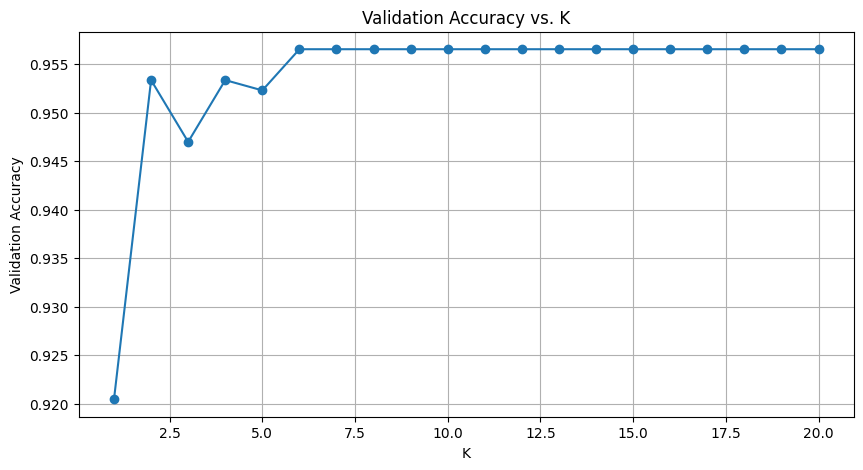

In [39]:
plt.figure(figsize=(10, 5))
plt.plot(k_values, val_accuracies, marker='o')
plt.title('Validation Accuracy vs. K')
plt.xlabel('K')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

In [40]:
best_k = k_values[val_accuracies.index(max(val_accuracies))]
print(f"Best K found on validation set: {best_k}")

Best K found on validation set: 6


**Train final model for best k**

In [41]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, y_train)
y_test_pred = final_knn.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Final Test Set Accuracy: {test_accuracy:.4f}")

Final Test Set Accuracy: 0.9491


# Cross-Validation using 5-fold

In [ ]:
cv_scores = cross_val_score(final_knn, x, y, cv=5, scoring='accuracy') #implement cross validation
average_cv_accuracy = np.mean(cv_scores) #avg score

train_accuracy = final_knn.score(X_train, y_train) #train accuracy

print(f"Cross-Validation Accuracies: {cv_scores}")
print(f"Average Cross-Validation Accuracy: {average_cv_accuracy:.4f}")
print(f"Final Test Set Accuracy: {test_accuracy:.4f}")

print("\n=== Comparison ===")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Set Best Accuracy: {max(val_accuracies):.4f}")
print(f"Cross-Validation Average Accuracy: {average_cv_accuracy:.4f}")
print(f"Test Set Accuracy: {test_accuracy:.4f}")

Cross-Validation Accuracies: [0.95227996 0.95440085 0.95546129 0.95546129 0.95546129]
Average Cross-Validation Accuracy: 0.9546
Final Test Set Accuracy: 0.9491

=== Comparison ===
Training Accuracy: 0.9576
Validation Set Best Accuracy: 0.9565
Cross-Validation Average Accuracy: 0.9546
Test Set Accuracy: 0.9491


>⚠️ **Accuracy of all is very close**

**Cross-validation is usually more robust because**:


*   It uses different training-validation splits multiple times.
*   It gives a more reliable performance estimate than just a single validation split.
*   It helps to avoid the risk that you got "lucky" or "unlucky" with one particular validation set.
*   The Test Set is never touched during model selection — only for final evaluation


























# Confusion Matrix and Classification Report

In [43]:
cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[894   2]
 [ 46   1]]


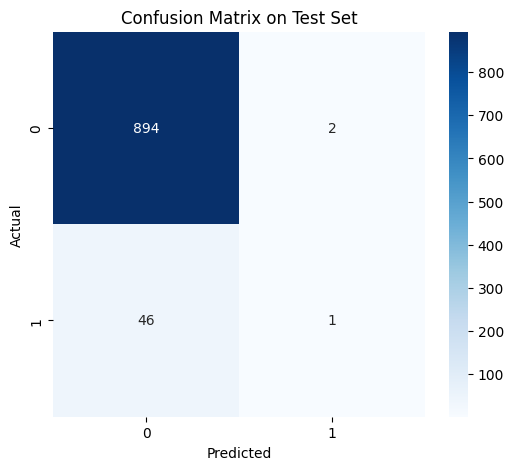

In [44]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [45]:
report = classification_report(y_test, y_test_pred, digits=4)
print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

         0.0     0.9511    0.9978    0.9739       896
         1.0     0.3333    0.0213    0.0400        47

    accuracy                         0.9491       943
   macro avg     0.6422    0.5095    0.5069       943
weighted avg     0.9203    0.9491    0.9273       943



**Important note**

In [46]:
data['stroke'].value_counts()

,count
stroke,
0.0,4506
1.0,209


Actully, out model doesn't overfit due to training, test, validation and avg cross- validition doesn't differ much

training acc ~ 95%
test & validation & cross-validation average ~ 95.4%
so our model doesn't have any sign of overfitting



---


but we have to notice something
1.   imbalance of data: data is very biased to negative diagnosis
2.   if we look in confusion matrix we can see that model predict only one true postive and he predicted 46 false negative
3.   in report the racall of is 2% which is very bad

**all of these ensure that our model is very biased to negative diagnosis**

Unfortunately, it is hard to slove in our sitiuation and using KNN

# impelementing Feature Selection Technique to solve overfitting (as required)

*Why Feature Selection?*

**because it reduce complexity of model as we have many columns and few rows (5000)**

**make model learn instead of memorize**

**Selecting most important features based on random forset classification**

In [47]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': data.columns.drop('stroke'), 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)
print("\nFeature Importances:")
print(feature_importance_df)


Feature Importances:
                           Feature  Importance
6                avg_glucose_level    0.271492
7                              bmi    0.245276
1                              age    0.226162
0                           gender    0.035003
5                   Residence_type    0.032834
9                work_type_Private    0.027412
12  smoking_status_formerly smoked    0.026447
13     smoking_status_never smoked    0.026386
2                     hypertension    0.024873
3                    heart_disease    0.021384
14           smoking_status_smokes    0.018432
10         work_type_Self-employed    0.018261
4                     ever_married    0.014897
11              work_type_children    0.007785
8           work_type_Never_worked    0.003354
15              smoking_status_nan    0.000000


<ipython-input-48-f4c8c89b7a69>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


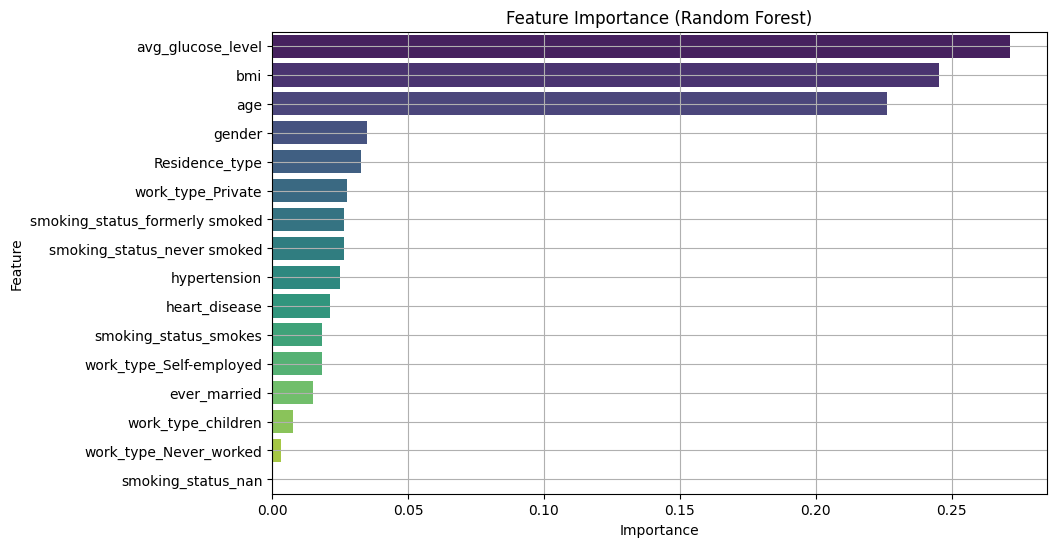

In [48]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(True)
plt.show()

**Using Correlation Matrix as well**

age                               0.236299
hypertension                      0.143461
avg_glucose_level                 0.141700
heart_disease                     0.137177
ever_married                      0.106713
smoking_status_formerly smoked    0.042660
bmi                               0.042518
work_type_Self-employed           0.039927
work_type_Private                 0.029282
smoking_status_smokes             0.022818
smoking_status_never smoked       0.009409
Residence_type                    0.007219
gender                            0.006482
work_type_Never_worked            0.000375
work_type_children               -0.076822
smoking_status_nan                     NaN
Name: Target, dtype: float64


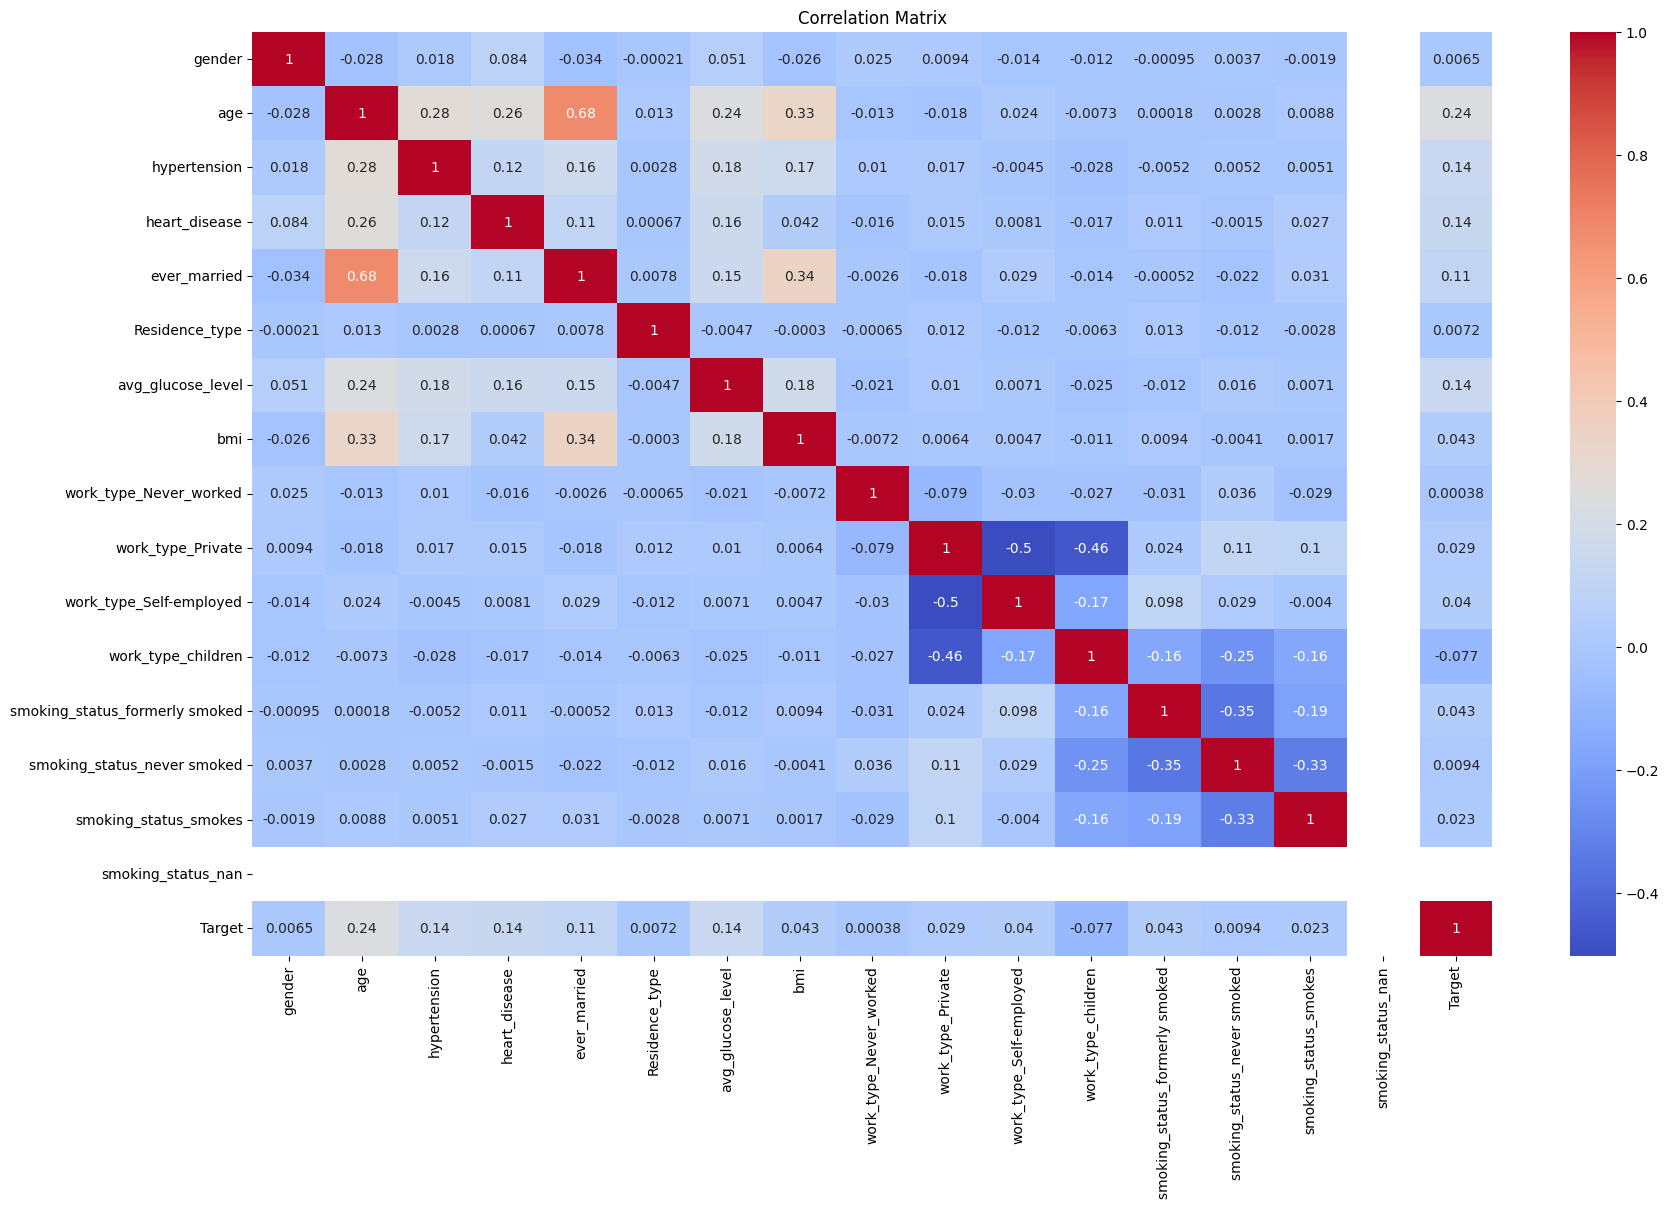

In [49]:

# Combine X and y into one DataFrame
data_with_target = data.drop('stroke', axis=1)
data_with_target['Target'] = y

# Calculate correlation matrix
corr_matrix = data_with_target.corr()

# Show correlation with the target
target_corr = corr_matrix['Target'].drop('Target')  # exclude self-correlation

# Sort features by importance
print(target_corr.sort_values(ascending=False))

# Plot heatmap
plt.figure(figsize=(20,12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Select feature based on previous results and fit again

**Features have strong relation to target and most important**

In [50]:
X_selected = data[['age' ,'bmi','avg_glucose_level','heart_disease']]
X_train_sel, X_temp_sel, y_train_sel, y_temp_sel = train_test_split(X_selected, y, test_size=0.4, random_state=42, stratify=y)
X_val_sel, X_test_sel, y_val_sel, y_test_sel = train_test_split(X_temp_sel, y_temp_sel, test_size=0.5, random_state=42, stratify=y_temp_sel)


**Scaling Features**

In [51]:
X_train_sel = scaler.fit_transform(X_train_sel)
X_val_sel = scaler.transform(X_val_sel)
X_test_sel = scaler.transform(X_test_sel)


**Fit and see accuracy**

In [52]:
knn_sel = KNeighborsClassifier(n_neighbors=best_k)
knn_sel.fit(X_train_sel, y_train_sel)

y_val_pred_sel = knn_sel.predict(X_val_sel)
y_test_pred_sel = knn_sel.predict(X_test_sel)

val_accuracy_sel = accuracy_score(y_val_sel, y_val_pred_sel)
test_accuracy_sel = accuracy_score(y_test_sel, y_test_pred_sel)

print(f"\nNew Validation Accuracy : {val_accuracy_sel:.4f}")
print(f"New Test Accuracy : {test_accuracy_sel:.4f}")


New Validation Accuracy : 0.9555
New Test Accuracy : 0.9523


**There is little improvment in our model and we successed in reducing overfitting**